In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn import base

In [39]:
df_train = pd.read_csv('./train.csv')
df_test = pd.read_csv('./test.csv')

df_train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [40]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [41]:
X = df_train.drop(['SalePrice'], axis=1)  
Y = df_train['SalePrice']                

In [42]:
X

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal


In [43]:
Y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

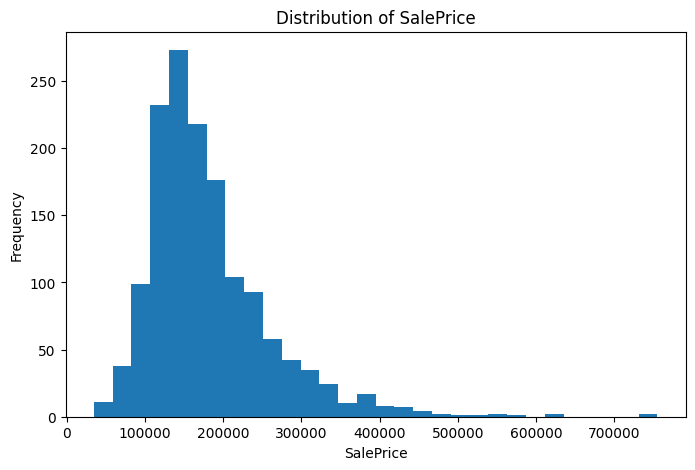

In [44]:
X=df_train.drop(['SalePrice'], axis=1)
y=df_train['SalePrice']

plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.title('Distribution of SalePrice')
plt.show()

In [45]:
def train_model(X_data, y_data):
  X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  r2 = r2_score(y_test, y_pred)

  return model, rmse, r2


RMSE-Root Mean Squared Error; This is the average error in dollars. Getting a lower rmse is better

R2 Score; This is how much variance the model explains . The higher r2 the better the predictions

RMSE as % of Average; This gives perspective on the erro size.

Encoding 
Method 1- Label encoding: This refers to the encoding method of changing categorical data to numerics forexample substituting 1 for male and 2 for female

In [55]:
from sklearn.preprocessing import LabelEncoder

train_label = pd.DataFrame()
label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':  
        
        X_col = X[col].fillna('Missing')
        train_label[col] = label_encoder.fit_transform(X_col.astype(str))
    else:
        train_label[col] = X[col].fillna(0)

train_label.head(5)

train_model(train_label, y)



(LinearRegression(), np.float64(34119.50781115316), 0.84822799163554)

Method 2 - One-Hot Encoding: This is another encoding method that 
converts category lables into numerical format with 1s and 0s; 
say binary form so a machine can understand them.

In [47]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

X_cat_clean = X[categorical_cols].fillna('Missing')
X_num_clean = X[numerical_cols].fillna(0)

X_cat_encoded = one_hot_encoder.fit_transform(X_cat_clean.astype(str))

X_cat_df = pd.DataFrame(X_cat_encoded, columns=one_hot_encoder.get_feature_names_out(categorical_cols))

X_one_hot = pd.concat([X_num_clean.reset_index(drop=True), X_cat_df], axis=1)

train_model(X_one_hot, y)

(LinearRegression(), np.float64(65346.15803643808), 0.44329351128221617)

Method 3 - Feature Hashing: This is a fast and memory efficient method used
to convert categorical data into fixed size numerical vector.

In [48]:
from sklearn.feature_extraction import FeatureHasher

X_hash_data = X.copy()
for col in X_hash_data.columns:
    X_hash_data[col] = X_hash_data[col].fillna('Missing').astype(str)

hasher = FeatureHasher(n_features=100, input_type='string')
X_hashed = hasher.transform(X_hash_data.values.astype(str))

X_train, X_test, y_train, y_test = train_test_split(X_hashed, y, random_state=42, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)


Method 4 - Frequency encoding; This is a technique that replaces categorical values with numbers based on how often t
hey appear in a dataset/ their frequencies in the dataset. Forexample if in a dataset of fruits, 
if oranges appear 20 times and apples 30 times,  the apples will be captured as 0.3  and oranges as 0.2 

In [49]:
X_freq = X.copy()

for col in X_freq.columns:
    if X_freq[col].dtype == 'object':
        X_freq[col] = X_freq[col].fillna('Missing')
        freq_map = X_freq[col].value_counts().to_dict()
        X_freq[col] = X_freq[col].map(freq_map)

X_freq = X_freq.fillna(0)

train_model(X_freq, y)

(LinearRegression(), np.float64(33687.393742376655), 0.8520479486138975)

Encoding combinations
1. Label and one hot encoding  for the nominal features in the dataset

In [50]:

ordinal_features = ['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 
                    'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual',
                    'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC',
                    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

nominal_features = [col for col in X.columns if col not in ordinal_features and X[col].dtype == 'object']

X_combined1 = pd.DataFrame()

label_encoder = LabelEncoder()
for col in ordinal_features:
    if col in X.columns:
        X_col = X[col].fillna('Missing').astype(str)
        X_combined1[col + '_label'] = label_encoder.fit_transform(X_col)

nominal_present = [col for col in nominal_features if col in X.columns]
if nominal_present:
    X_nominal = X[nominal_present].fillna('Missing')
    one_hot_encoder_comb1 = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_nom_encoded = one_hot_encoder_comb1.fit_transform(X_nominal.astype(str))
    X_nom_df = pd.DataFrame(X_nom_encoded, columns=one_hot_encoder_comb1.get_feature_names_out(nominal_present))
    X_combined1 = pd.concat([X_combined1, X_nom_df], axis=1)

numerical_cols = X.select_dtypes(exclude=['object']).columns
X_num_clean = X[numerical_cols].fillna(0)
X_combined1 = pd.concat([X_num_clean.reset_index(drop=True), X_combined1], axis=1)


train_model(X_combined1, y)

(LinearRegression(), np.float64(29974.4182163107), 0.8828647278958706)

2. Feature hashing and frequency encoding; We use frequency encoding for important categorical features and feature hashing for high cardinality features to save memory

In [51]:

high_cardinality_features = ['Neighborhood', 'Exterior1st', 'Exterior2nd', 'GarageType', 
                             'SaleType', 'SaleCondition', 'MSZoning', 'HouseStyle']

frequency_features = [col for col in X.columns if X[col].dtype == 'object' 
                      and col not in high_cardinality_features]

X_combined2 = pd.DataFrame()
X_hash_data = pd.DataFrame()

for col in frequency_features:
    if col in X.columns:
        X_col = X[col].fillna('Missing')
        freq_map = X_col.value_counts().to_dict()
        X_combined2[col + '_freq'] = X_col.map(freq_map)

hash_cols = [col for col in high_cardinality_features if col in X.columns]
if hash_cols:
    X_hash_temp = X[hash_cols].fillna('Missing')
    for col in hash_cols:
        X_hash_temp[col] = X_hash_temp[col].astype(str)
    
    hasher = FeatureHasher(n_features=50, input_type='string')
    X_hashed_comb2 = hasher.transform(X_hash_temp.values.astype(str))
    X_hash_df = pd.DataFrame(X_hashed_comb2.toarray(), 
                            columns=[f'hash_{i}' for i in range(X_hashed_comb2.shape[1])])
    X_combined2 = pd.concat([X_combined2, X_hash_df], axis=1)

numerical_cols = X.select_dtypes(exclude=['object']).columns
X_num_clean = X[numerical_cols].fillna(0)
X_combined2 = pd.concat([X_num_clean.reset_index(drop=True), X_combined2], axis=1)

X_combined2 = X_combined2.fillna(0)

train_model(X_combined2, y)

(LinearRegression(), np.float64(31824.23004099688), 0.8679610761856116)

Comparison Summary

 FINAL SUMMARY: COMPARISON OF ALL ENCODING METHODS
 COMPARISON TABLE

Method                                RMSE ($)     R² Score           Data Shape
1. Label Encoding                    34,119.51       0.8482           (1460, 80)
2. One-Hot Encoding                  65,346.16       0.4433          (1460, 304)
3. Feature Hashing                   51,255.43       0.6575          (1460, 100)
4. Frequency Encoding                33,687.39       0.8520           (1460, 80)
5. Label + One-Hot                   29,974.42       0.8829          (1460, 250)
6. Hashing + Frequency               31,824.23       0.8680          (1460, 122)
  BEST PERFORMING METHOD
  Best Method: 5. Label + One-Hot
   RMSE: $29,974.42
   R² Score: 0.8829
   Data Shape: (1460, 250)


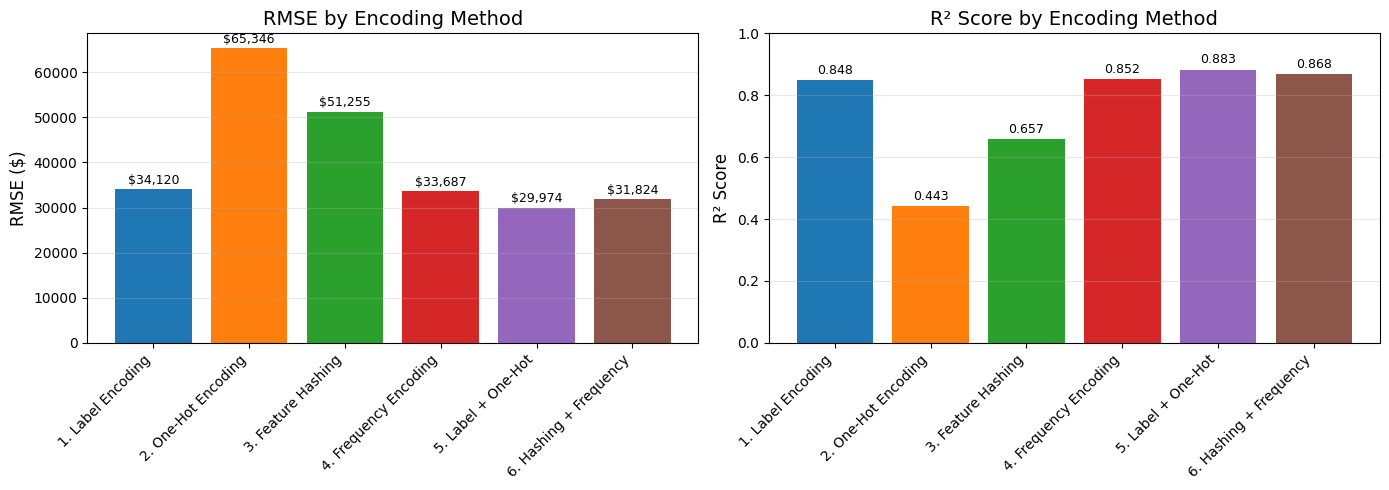

In [53]:
print(" FINAL SUMMARY: COMPARISON OF ALL ENCODING METHODS")

# Re-evaluating all methods and storing results properly
results = []

# 1. Label Encoding
model1, rmse1, r2_1 = train_model(train_label, y)
results.append({
    'Method': '1. Label Encoding',
    'RMSE': rmse1,
    'R²': r2_1,
    'Shape': str(train_label.shape)
})

# 2. One-Hot Encoding
model2, rmse2, r2_2 = train_model(X_one_hot, y)
results.append({
    'Method': '2. One-Hot Encoding',
    'RMSE': rmse2,
    'R²': r2_2,
    'Shape': str(X_one_hot.shape)
})

# 3. Feature Hashing
X_train, X_test, y_train, y_test = train_test_split(X_hashed, y, random_state=42, test_size=0.2)
model3 = LinearRegression()
model3.fit(X_train, y_train)
pred3 = model3.predict(X_test)
rmse3 = np.sqrt(mean_squared_error(y_test, pred3))
r2_3 = r2_score(y_test, pred3)
results.append({
    'Method': '3. Feature Hashing',
    'RMSE': rmse3,
    'R²': r2_3,
    'Shape': str(X_hashed.shape)
})

# 4. Frequency Encoding
model4, rmse4, r2_4 = train_model(X_freq, y)
results.append({
    'Method': '4. Frequency Encoding',
    'RMSE': rmse4,
    'R²': r2_4,
    'Shape': str(X_freq.shape)
})

# 5. Label + One-Hot
model5, rmse5, r2_5 = train_model(X_combined1, y)
results.append({
    'Method': '5. Label + One-Hot',
    'RMSE': rmse5,
    'R²': r2_5,
    'Shape': str(X_combined1.shape)
})

# 6. Hashing + Frequency
model6, rmse6, r2_6 = train_model(X_combined2, y)
results.append({
    'Method': '6. Hashing + Frequency',
    'RMSE': rmse6,
    'R²': r2_6,
    'Shape': str(X_combined2.shape)
})

# Creating summary DataFrame
summary_df = pd.DataFrame(results)

print(" COMPARISON TABLE")


# Displaying formatted table
print("\n{:<30} {:>15} {:>12} {:>20}".format('Method', 'RMSE ($)', 'R² Score', 'Data Shape'))
for _, row in summary_df.iterrows():
    print("{:<30} {:>15,.2f} {:>12.4f} {:>20}".format(
        row['Method'], row['RMSE'], row['R²'], row['Shape']
    ))

# Finding the best method
best_idx = summary_df['RMSE'].idxmin()
best_row = summary_df.loc[best_idx]

print("  BEST PERFORMING METHOD")
print(f"  Best Method: {best_row['Method']}")
print(f"   RMSE: ${best_row['RMSE']:,.2f}")
print(f"   R² Score: {best_row['R²']:.4f}")
print(f"   Data Shape: {best_row['Shape']}")


plt.figure(figsize=(14, 5))

# RMSE Comparison
plt.subplot(1, 2, 1)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
bars = plt.bar(summary_df['Method'], summary_df['RMSE'], color=colors)
plt.title('RMSE by Encoding Method', fontsize=14)
plt.ylabel('RMSE ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for bar, rmse in zip(bars, summary_df['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'${rmse:,.0f}', ha='center', va='bottom', fontsize=9)

# R² Comparison
plt.subplot(1, 2, 2)
bars2 = plt.bar(summary_df['Method'], summary_df['R²'], color=colors)
plt.title('R² Score by Encoding Method', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
for bar, r2 in zip(bars2, summary_df['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{r2:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

